In [3]:
import kagglehub
import os

In [4]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

base = os.path.join(path, "chest_xray")
print(base)

/Users/aarondang/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray


In [5]:
print(os.listdir(base))

['test', 'chest_xray', '__MACOSX', 'train', 'val']


In [6]:
def count_images(split):
    split_path = os.path.join(base, split)
    counts = {}

    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = os.path.join(split_path, cls)
        counts[cls] = len(os.listdir(cls_path))

    return counts


train_counts = count_images("train")
val_counts = count_images("val")
test_counts = count_images("test")

print("Train:", train_counts)
print("Val:", val_counts)
print("Test:", test_counts)

Train: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Val: {'NORMAL': 8, 'PNEUMONIA': 8}
Test: {'NORMAL': 234, 'PNEUMONIA': 390}


Matplotlib is building the font cache; this may take a moment.


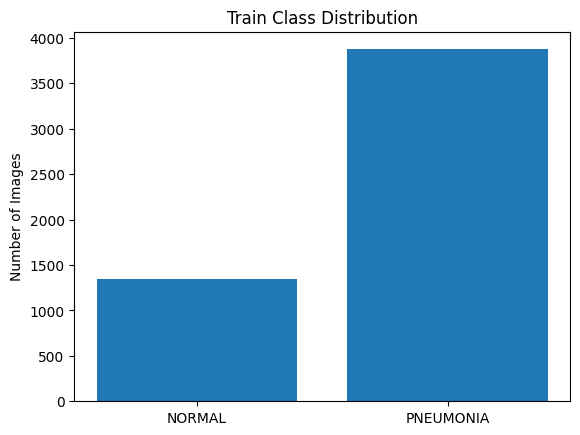

In [7]:
import matplotlib.pyplot as plt

labels = list(train_counts.keys())
values = list(train_counts.values())

plt.figure()
plt.bar(labels, values)
plt.title("Train Class Distribution")
plt.ylabel("Number of Images")
plt.show()

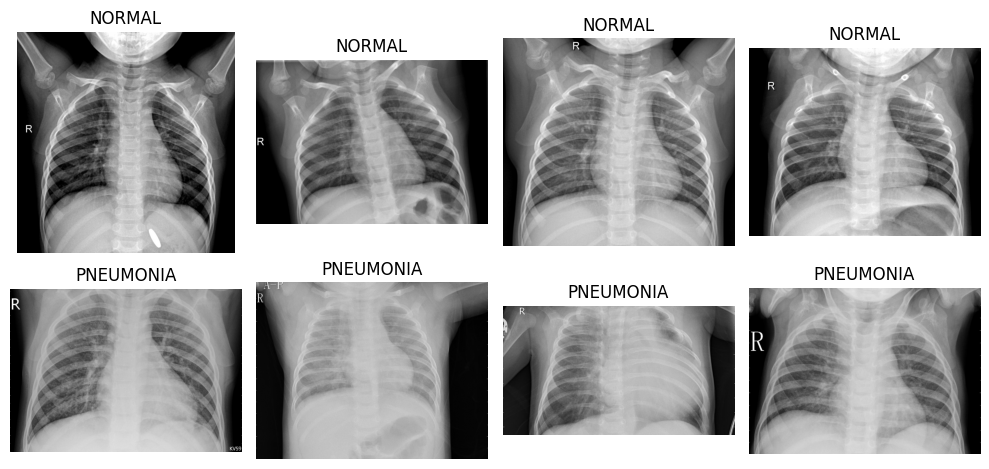

In [8]:
import random
from PIL import Image

def show_samples(class_name, n=4):
    folder = os.path.join(base, "train", class_name)
    files = random.sample(os.listdir(folder), n)
    return [Image.open(os.path.join(folder, f)) for f in files]


normal_imgs = show_samples("NORMAL", 4)
pneumonia_imgs = show_samples("PNEUMONIA", 4)

plt.figure(figsize=(10,5))

for i, img in enumerate(normal_imgs + pneumonia_imgs):
    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL" if i < 4 else "PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

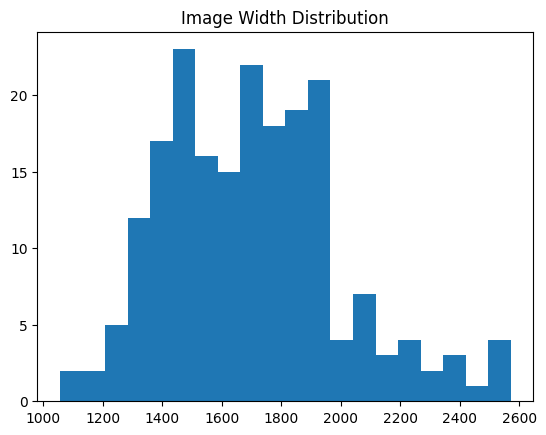

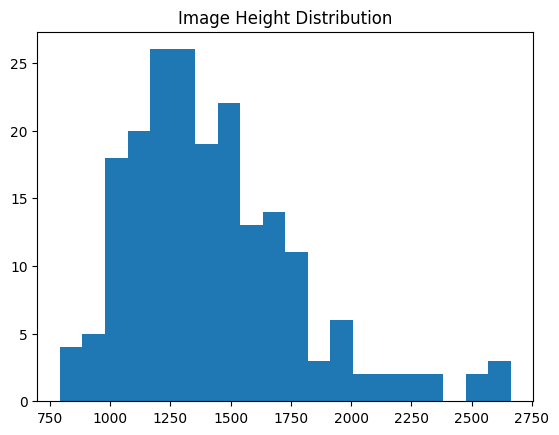

In [9]:
import numpy as np

widths = []
heights = []

sample_dir = os.path.join(base, "train", "NORMAL")
files = os.listdir(sample_dir)[:200]

for f in files:
    img = Image.open(os.path.join(sample_dir, f))
    w, h = img.size
    widths.append(w)
    heights.append(h)

plt.figure()
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

plt.figure()
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.show()

In [10]:
normal = train_counts["NORMAL"]
pneumonia = train_counts["PNEUMONIA"]

ratio = pneumonia / normal

print("NORMAL:", normal)
print("PNEUMONIA:", pneumonia)
print("Pneumonia-to-Normal ratio:", round(ratio, 2))

NORMAL: 1341
PNEUMONIA: 3875
Pneumonia-to-Normal ratio: 2.89


In [11]:
import sys
sys.path.append("../")

In [12]:
import os
print(os.listdir("../"))

['requirements.txt', 'results', '.gitignore', '.ipynb_checkpoints', '.vscode', 'data', 'notebooks', 'src']


In [13]:
print(os.listdir("../src"))

['config.py', 'datasets.py', '__init__.py']


In [15]:
from src.datasets import get_dataloaders
print("import worked")

import worked


In [18]:
from src.datasets import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(base)

print(len(train_loader), len(val_loader), len(test_loader))

163 1 20
